In [1]:
!pip install imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [2]:
#1 Load data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

col_names = [
    "checking_status", "duration", "credit_history", "purpose",
    "credit_amount", "savings", "employment", "installment_rate",
    "personal_status", "other_debtors", "residence_since", "property",
    "age", "other_installment", "housing", "existing_credits",
    "job", "liable_people", "telephone", "foreign_worker", "target"
]

df = pd.read_csv(url, sep=" ", header=None, names=col_names)

# Target: 1 = Good, 2 = Bad → recode to 0 = Good, 1 = Bad (standard convention)
df["target"] = df["target"].map({1: 0, 2: 1})

print("Shape:", df.shape)
print("\nClass distribution:\n", df["target"].value_counts())
print("\nSample:\n", df.head(3))

Shape: (1000, 21)

Class distribution:
 target
0    700
1    300
Name: count, dtype: int64

Sample:
   checking_status  duration credit_history purpose  credit_amount savings  \
0             A11         6            A34     A43           1169     A65   
1             A12        48            A32     A43           5951     A61   
2             A14        12            A34     A46           2096     A61   

  employment  installment_rate personal_status other_debtors  ...  property  \
0        A75                 4             A93          A101  ...      A121   
1        A73                 2             A92          A101  ...      A121   
2        A74                 2             A93          A101  ...      A121   

  age  other_installment housing existing_credits   job liable_people  \
0  67               A143    A152                2  A173             1   
1  22               A143    A152                1  A173             1   
2  49               A143    A152                1  A17

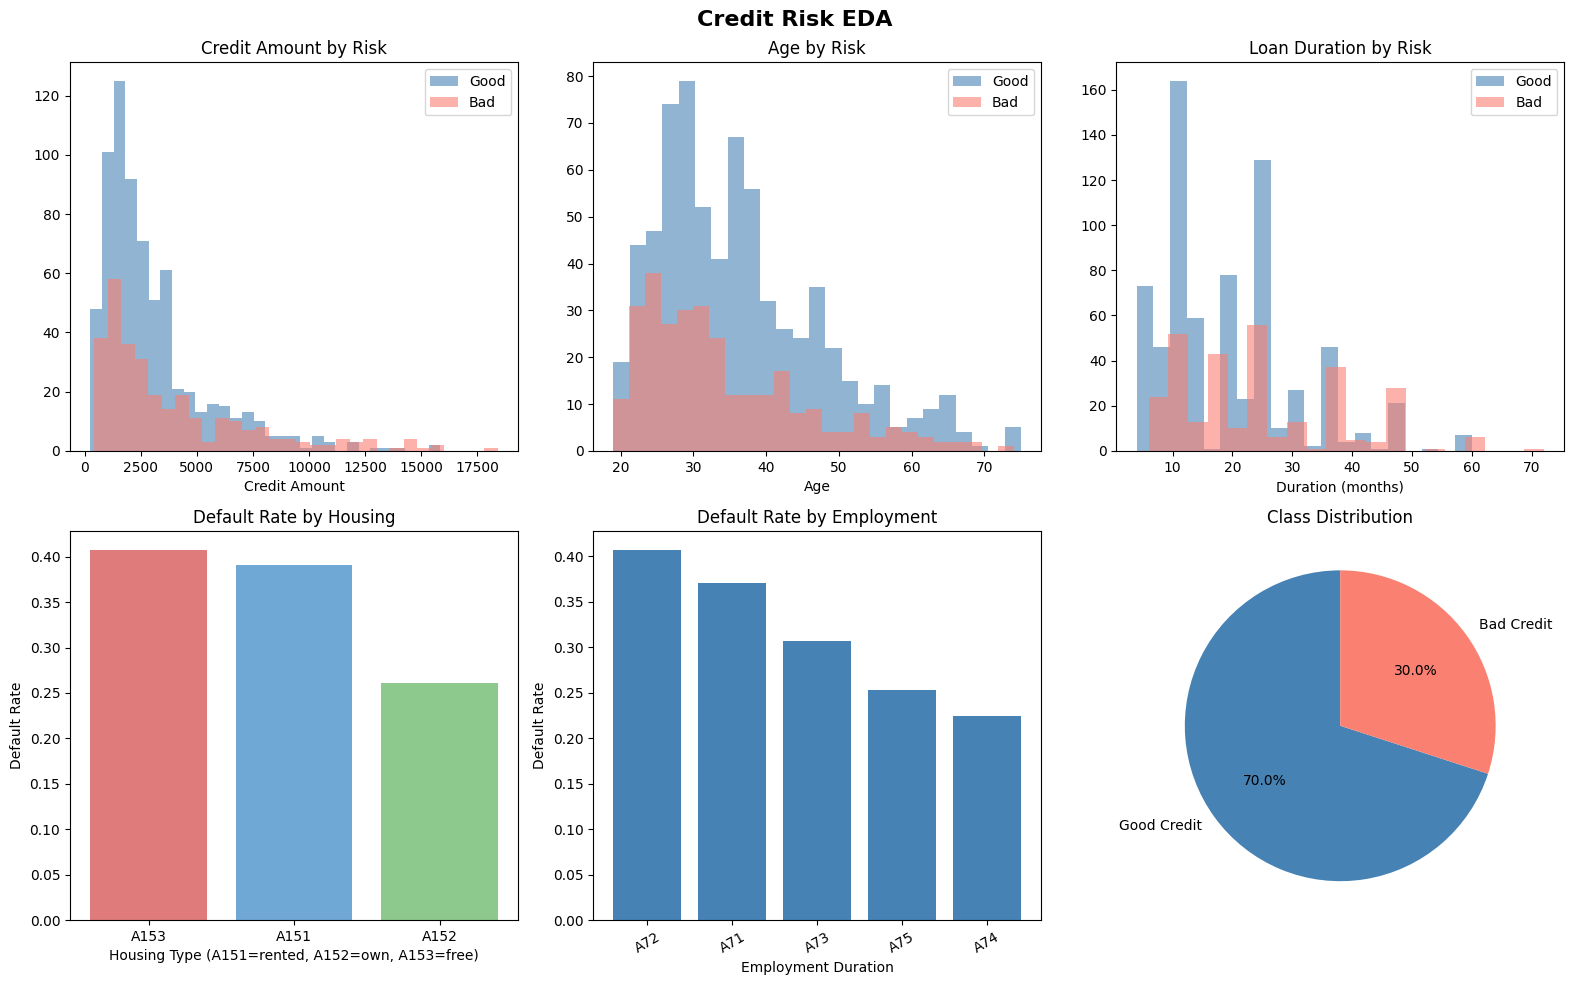

EDA plots saved.


In [3]:
#2 EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Credit Risk EDA", fontsize=16, fontweight="bold")

# Credit amount distribution
axes[0, 0].hist(df[df.target==0]["credit_amount"], alpha=0.6, bins=30, label="Good", color="steelblue")
axes[0, 0].hist(df[df.target==1]["credit_amount"], alpha=0.6, bins=30, label="Bad", color="salmon")
axes[0, 0].set_title("Credit Amount by Risk")
axes[0, 0].set_xlabel("Credit Amount")
axes[0, 0].legend()

# Age distribution
axes[0, 1].hist(df[df.target==0]["age"], alpha=0.6, bins=25, label="Good", color="steelblue")
axes[0, 1].hist(df[df.target==1]["age"], alpha=0.6, bins=25, label="Bad", color="salmon")
axes[0, 1].set_title("Age by Risk")
axes[0, 1].set_xlabel("Age")
axes[0, 1].legend()

# Duration distribution
axes[0, 2].hist(df[df.target==0]["duration"], alpha=0.6, bins=20, label="Good", color="steelblue")
axes[0, 2].hist(df[df.target==1]["duration"], alpha=0.6, bins=20, label="Bad", color="salmon")
axes[0, 2].set_title("Loan Duration by Risk")
axes[0, 2].set_xlabel("Duration (months)")
axes[0, 2].legend()

# Default rate by housing
housing_risk = df.groupby("housing")["target"].mean().sort_values(ascending=False)
axes[1, 0].bar(housing_risk.index, housing_risk.values, color=["#e07b7b","#6fa8d4","#8dc88d"])
axes[1, 0].set_title("Default Rate by Housing")
axes[1, 0].set_ylabel("Default Rate")
axes[1, 0].set_xlabel("Housing Type (A151=rented, A152=own, A153=free)")

# Default rate by employment
emp_risk = df.groupby("employment")["target"].mean().sort_values(ascending=False)
axes[1, 1].bar(emp_risk.index, emp_risk.values, color="steelblue")
axes[1, 1].set_title("Default Rate by Employment")
axes[1, 1].set_ylabel("Default Rate")
axes[1, 1].set_xlabel("Employment Duration")
axes[1, 1].tick_params(axis='x', rotation=30)

# Target class pie
axes[1, 2].pie(df["target"].value_counts(), labels=["Good Credit", "Bad Credit"],
               autopct="%1.1f%%", colors=["steelblue", "salmon"], startangle=90)
axes[1, 2].set_title("Class Distribution")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved.")

**EDA Insights**

1. Free housing (A153) has the highest default rate (~ 40%), outpacing rented housing  
2. Shorter employment duration (A72) correlated with the highest default rate (~ 42%)  
3. Bad credit applicants cluster heavily in the under-2500 DM credit amount range  
4. Younger applicants (20s - 30s) show propotionally higher bad credit rates



In [4]:
#3 Preprocessing

from imblearn.over_sampling import SMOTE   # NEW: add this import at top ideally

# Encode all categorical features
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include="object").columns

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

# Split FIRST, then apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── NEW: Apply SMOTE to training set only ──────────────────
smote = SMOTE(random_state=42, sampling_strategy=0.6)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"After SMOTE → Train size: {len(X_train)} | Class balance: {pd.Series(y_train).value_counts().to_dict()}")
# ──────────────────────────────────────────────────────────

print(f"Test size: {X_test.shape[0]} (unchanged)")

After SMOTE → Train size: 896 | Class balance: {0: 560, 1: 336}
Test size: 200 (unchanged)


The dataset has a 70/30 split. SMOTE was applied exclusively to the training set after the train/test split to avoid data leakage. A sampling strategy of 0.6 was used rather than full 50/50 balance to prevent models from over-learning synthetic patterns.

In [5]:
#4 Model Training

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth = 3, subsample = 0.8, min_samples_leaf=20, random_state=42))
    ])
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in models.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        "pipeline": pipeline,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "test_auc": auc,
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Good", "Bad"]))


Model: Logistic Regression
  CV AUC: 0.8219 ± 0.0105
  Test AUC: 0.7863
              precision    recall  f1-score   support

        Good       0.83      0.85      0.84       140
         Bad       0.63      0.60      0.62        60

    accuracy                           0.78       200
   macro avg       0.73      0.72      0.73       200
weighted avg       0.77      0.78      0.77       200


Model: Random Forest
  CV AUC: 0.8535 ± 0.0092
  Test AUC: 0.7897
              precision    recall  f1-score   support

        Good       0.80      0.89      0.84       140
         Bad       0.64      0.48      0.55        60

    accuracy                           0.77       200
   macro avg       0.72      0.68      0.70       200
weighted avg       0.75      0.77      0.75       200


Model: Gradient Boosting
  CV AUC: 0.8393 ± 0.0117
  Test AUC: 0.7989
              precision    recall  f1-score   support

        Good       0.83      0.84      0.83       140
         Bad       0.61   

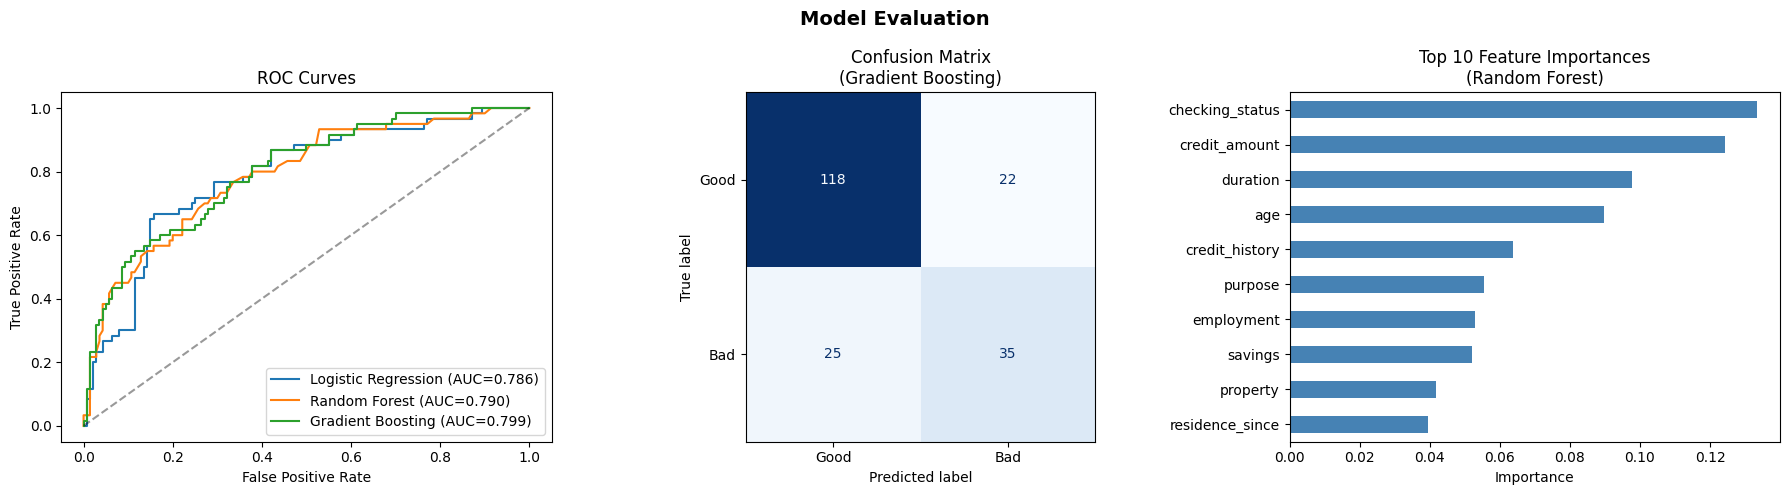

Model evaluation plots saved.


In [6]:
#5 Evaluation

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation", fontsize=14, fontweight="bold")

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.3f})")
axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

# Confusion Matrix (best model by AUC)
best_name = max(results, key=lambda k: results[k]["test_auc"])
best = results[best_name]
cm = confusion_matrix(y_test, best["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Good", "Bad"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix\n({best_name})")

# Feature Importance (Random Forest)
rf_clf = results["Random Forest"]["pipeline"].named_steps["clf"]
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
importances.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top 10 Feature Importances\n(Random Forest)")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Model evaluation plots saved.")

**Graph Interpretation**  

***ROC Curves***  

All three models perform well above the diagonal conforming general predictive power. Gradient Boosting narrowly edges out Random Forest and Logistic Regression. The curves rise steeply in the early low false-positive region, which is exactly what you want in lending: the model can catch a good chunk of bad applicants before it starts incorrectly flagging good ones.  

***Confusion Matrix***  
* 118 true negatives - correctly approved good applicants, no lost revenue
* 35 true positives - correctly flagged bad applicants, losses avoided
* 22 false positives - good applicants incorrectly rejected, these are missed business opportunities
* 25 false negatives - bad applicants incorrectly approved, **these are your real financial risk**  

***Top 10 Features Importances (Random Forest)***  
* **checking_status** is by far the strongest predictor dwarfing everything else. Whether someone has a positive, negative, or no checking account balance is the single best signal of creditworthiness. This makes intuitive sense: it reflects real-time financial behaviour.  

* **credit_amount** and **duration** rank second and third: larger loans over longer periods carry more default risk, which aligns with the engineered monthly_burden feature adding value.  

* **age** ranking fourth is interesting: older applicants tend to be more financially stable, though this feature needs careful handling in production for fair lending compliance.  

* **credit_history, purpose, employment, savings** form a mid-tier cluster of behavioural and situational features; all sensible credit risk indicators.  

* **property** and **residence_since** at the bottom still contribute meaningful signal around financial stability and rootedness.

In [7]:
#6 Scorecard

print("\n===== PROBABILITY OF DEFAULT: Sample Predictions =====")
sample = X_test.head(10).copy()
sample["Actual"] = y_test.head(10).values
sample["PD (%)"] = (best["y_proba"][:10] * 100).round(2)
sample["Predicted Risk"] = sample["PD (%)"].apply(lambda x: "HIGH" if x > 50 else "LOW")
print(sample[["age","credit_amount","duration","Actual","PD (%)","Predicted Risk"]].to_string())





===== PROBABILITY OF DEFAULT: Sample Predictions =====
     age  credit_amount  duration  Actual  PD (%) Predicted Risk
30    36           1913        18       0   31.95            LOW
128   34           1860        12       0   18.86            LOW
289   48           1024        24       1   79.22           HIGH
216   31           3104        18       0   46.51            LOW
966   23           2520        27       1   22.25            LOW
346   23            882        13       0   20.48            LOW
537   37           3612        18       0   13.92            LOW
47    23           1352         6       0   40.19            LOW
112   28           6260        18       0   54.09           HIGH
875   40           1322        11       0   28.92            LOW


In [8]:
#7 Summary Table

print("\n===== MODEL COMPARISON SUMMARY =====")
summary = pd.DataFrame([{
    "Model": name,
    "CV AUC Mean": f"{r['cv_auc_mean']:.4f}",
    "CV AUC Std": f"±{r['cv_auc_std']:.4f}",
    "Test AUC": f"{r['test_auc']:.4f}"
} for name, r in results.items()])
print(summary.to_string(index=False))


===== MODEL COMPARISON SUMMARY =====
              Model CV AUC Mean CV AUC Std Test AUC
Logistic Regression      0.8219    ±0.0105   0.7863
      Random Forest      0.8535    ±0.0092   0.7897
  Gradient Boosting      0.8393    ±0.0117   0.7989



===== CALIBRATED GRADIENT BOOSTING =====
Calibrated Test AUC: 0.7836
              precision    recall  f1-score   support

        Good       0.82      0.86      0.84       140
         Bad       0.62      0.55      0.58        60

    accuracy                           0.77       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200


===== XGBOOST =====
XGBoost Test AUC: 0.7974
              precision    recall  f1-score   support

        Good       0.83      0.79      0.81       140
         Bad       0.55      0.62      0.58        60

    accuracy                           0.73       200
   macro avg       0.69      0.70      0.69       200
weighted avg       0.74      0.73      0.74       200


===== GRADIENT BOOSTING + ENGINEERED FEATURES =====
Engineered Features Test AUC: 0.8039
              precision    recall  f1-score   support

        Good       0.83      0.84      0.83       140
         Bad       0.61      0.

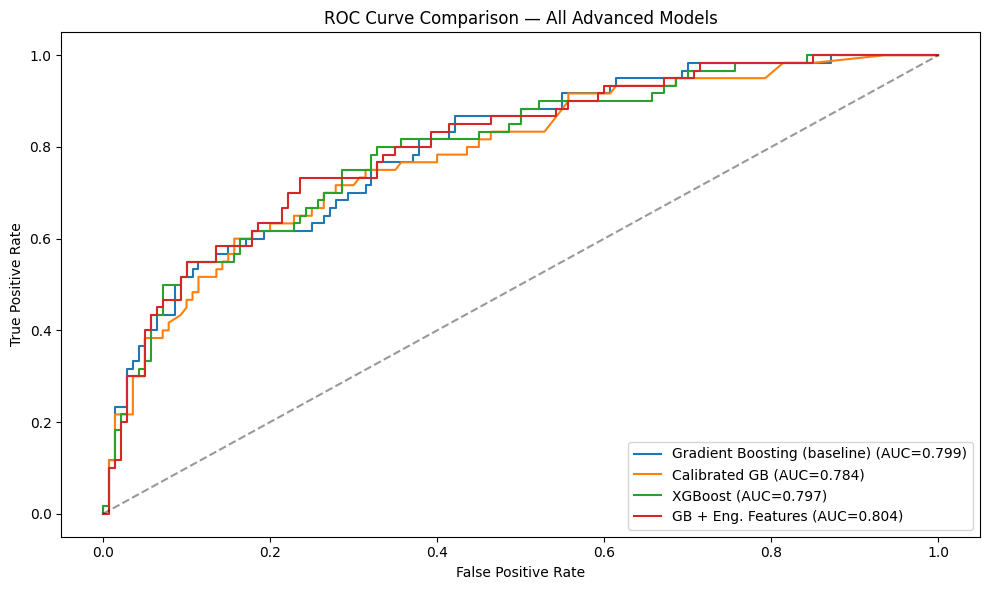


===== FINAL MODEL COMPARISON =====
              Model  Test AUC
 GB + Eng. Features  0.803929
  Gradient Boosting  0.798929
            XGBoost  0.797381
      Random Forest  0.789702
Logistic Regression  0.786310
      Calibrated GB  0.783571


In [9]:
#8 Advanced Models


# Fix 1: Probability Calibration
from sklearn.calibration import CalibratedClassifierCV

print("\n===== CALIBRATED GRADIENT BOOSTING =====")
gb_pipeline = results["Gradient Boosting"]["pipeline"]

calibrated = CalibratedClassifierCV(gb_pipeline, cv=5, method='isotonic')
calibrated.fit(X_train, y_train)

y_proba_cal = calibrated.predict_proba(X_test)[:, 1]
y_pred_cal = (y_proba_cal >= 0.50).astype(int)

print(f"Calibrated Test AUC: {roc_auc_score(y_test, y_proba_cal):.4f}")
print(classification_report(y_test, y_pred_cal, target_names=["Good", "Bad"]))


# Fix 2: XGBoost
!pip install xgboost -q

from xgboost import XGBClassifier

print("\n===== XGBOOST =====")
xgb = XGBClassifier(
    scale_pos_weight=2.3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

print(f"XGBoost Test AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=["Good", "Bad"]))


# Fix 3: Feature Engineering
print("\n===== GRADIENT BOOSTING + ENGINEERED FEATURES =====")

# Add to both train and test
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

X_train_eng["monthly_burden"] = X_train["credit_amount"] / (X_train["duration"] + 1)
X_train_eng["amount_per_age"]  = X_train["credit_amount"] / (X_train["age"] + 1)
X_train_eng["duration_x_rate"] = X_train["duration"] * X_train["installment_rate"]

X_test_eng["monthly_burden"]   = X_test["credit_amount"] / (X_test["duration"] + 1)
X_test_eng["amount_per_age"]   = X_test["credit_amount"] / (X_test["age"] + 1)
X_test_eng["duration_x_rate"]  = X_test["duration"] * X_test["installment_rate"]

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

gb_eng = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42
    ))
])

gb_eng.fit(X_train_eng, y_train)
y_proba_eng = gb_eng.predict_proba(X_test_eng)[:, 1]
y_pred_eng  = gb_eng.predict(X_test_eng)

print(f"Engineered Features Test AUC: {roc_auc_score(y_test, y_proba_eng):.4f}")
print(classification_report(y_test, y_pred_eng, target_names=["Good", "Bad"]))


# Final Comparison Plot
fig, ax = plt.subplots(figsize=(10, 6))

for label, y_p in [
    ("Gradient Boosting (baseline)", results["Gradient Boosting"]["y_proba"]),
    ("Calibrated GB",                y_proba_cal),
    ("XGBoost",                      y_proba_xgb),
    ("GB + Eng. Features",           y_proba_eng),
]:
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc = roc_auc_score(y_test, y_p)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")

ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — All Advanced Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("advanced_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Final Summary
print("\n===== FINAL MODEL COMPARISON =====")
final_summary = pd.DataFrame([
    {"Model": "Logistic Regression",    "Test AUC": results["Logistic Regression"]["test_auc"]},
    {"Model": "Random Forest",          "Test AUC": results["Random Forest"]["test_auc"]},
    {"Model": "Gradient Boosting",      "Test AUC": results["Gradient Boosting"]["test_auc"]},
    {"Model": "Calibrated GB",          "Test AUC": roc_auc_score(y_test, y_proba_cal)},
    {"Model": "XGBoost",                "Test AUC": roc_auc_score(y_test, y_proba_xgb)},
    {"Model": "GB + Eng. Features",     "Test AUC": roc_auc_score(y_test, y_proba_eng)},
]).sort_values("Test AUC", ascending=False)

print(final_summary.to_string(index=False))

**ROC Curves Interpretation**  

* All four curves are tightly bundled together throughout most of the chart which tells us that we have hit dataset ceiling and that all the advanced models are learning essentially the same signal from the same 1000 rows.  

* The early steep rise (FPR 0.0-0.3) is the most important reigon for a lender as it is  where the model catches bad applicants while barely touching the good ones.  

* The curves converge and nearly overlap from FPR 0.3 onwards and distinguishing between the models becomes almost impossible visually. The differences in the early low-FPR reigon, where GB + Eng. Features pulls its slight edge.  

* GB + Eng. Features pulls ahead in the high-recall zone (FPR 0.6-1.0). This means when you need to catch nearly all bad applicants regardless of false positives, the engineered features give the model an edge.

Overall this means that if your bank policy is to minimize bad loan approval at all costs operate in the top-left reigon(FPR < 0.2), all models perform similarly here so simplicity favours Logistic Regression.  
If you bank wants a balanced approval rate (FPR around 0.2-0.4) GB + Eng. Features and baseline GB are your best options as they hold a consistent edge over XGBoost and Calibrated GB in this zone.